In [1]:
!pip install yfinance

In [ ]:
#BLOCK 1 — Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
#BLOCK 2 — Download Stock Data

[*********************100%***********************]  1 of 1 completed


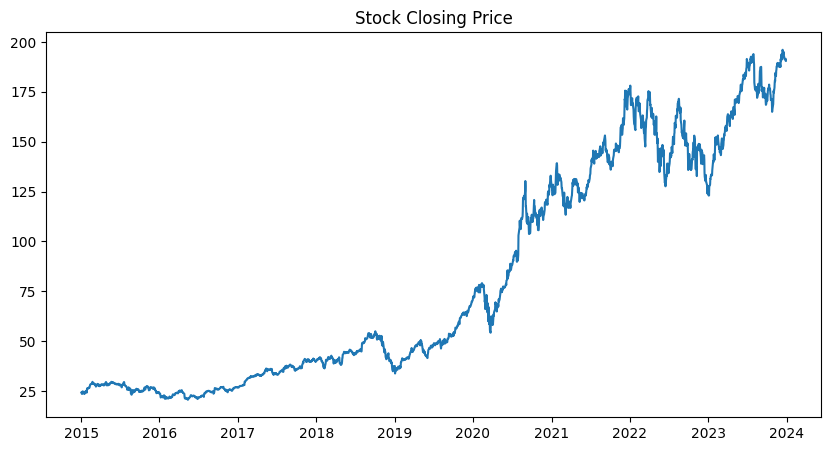

In [3]:
ticker = "AAPL"   # Change to any stock
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")

data = data[['Close']]
data.dropna(inplace=True)

plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Stock Closing Price")
plt.show()


In [ ]:
#BLOCK 3 — Preprocess & Create Sequences (30 Days)

In [4]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(dataset, time_steps=30):
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 30)


In [ ]:
#BLOCK 4 — Train / Validation / Test Split (70/20/10)

In [5]:
total = len(X)

train_end = int(0.7 * total)
val_end = int(0.9 * total)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (1563, 30, 1)
Val: (447, 30, 1)
Test: (224, 30, 1)


In [6]:
#BLOCK 5 — Define Callbacks

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)


In [8]:
#BLOCK 6 — Model A: Simple RNN

In [9]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(30,1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0018 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.8080e-04 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3318e-04 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3918e-04 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2172e-04 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2600e-04 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1988e-04 - val_loss: 7.9083e-04 - learning_rate: 0.0010
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2717e-04 - val_loss: 8.5970e-04 - learning_rate: 0.0010
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2625e-04 - val_loss: 0.0010 - 

In [10]:
#BLOCK 7 — Evaluate RNN

In [11]:
rnn_pred = rnn_model.predict(X_test)

rnn_mse = mean_squared_error(y_test, rnn_pred)
rnn_mae = mean_absolute_error(y_test, rnn_pred)

print("RNN Test MSE:", rnn_mse)
print("RNN Test MAE:", rnn_mae)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 
RNN Test MSE: 0.0024656000548219335
RNN Test MAE: 0.04385819441767732


In [12]:
#BLOCK 8 — Model B: LSTM

In [13]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(30,1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0125 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6662e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8749e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.5056e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2886e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3008e-04 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.2068e-04 - val_loss: 0.0016 - learning_rate: 5.0000e-04
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1769e-04 - val_loss: 0.0014 - learning_rate: 5.0000e-04
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.25

In [14]:
#BLOCK 9 — Evaluate LSTM

In [15]:
lstm_pred = lstm_model.predict(X_test)

lstm_mse = mean_squared_error(y_test, lstm_pred)
lstm_mae = mean_absolute_error(y_test, lstm_pred)

print("LSTM Test MSE:", lstm_mse)
print("LSTM Test MAE:", lstm_mae)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  
LSTM Test MSE: 0.00113047226806276
LSTM Test MAE: 0.024098957229993077


In [16]:
#BLOCK 11 — Prediction Visualization

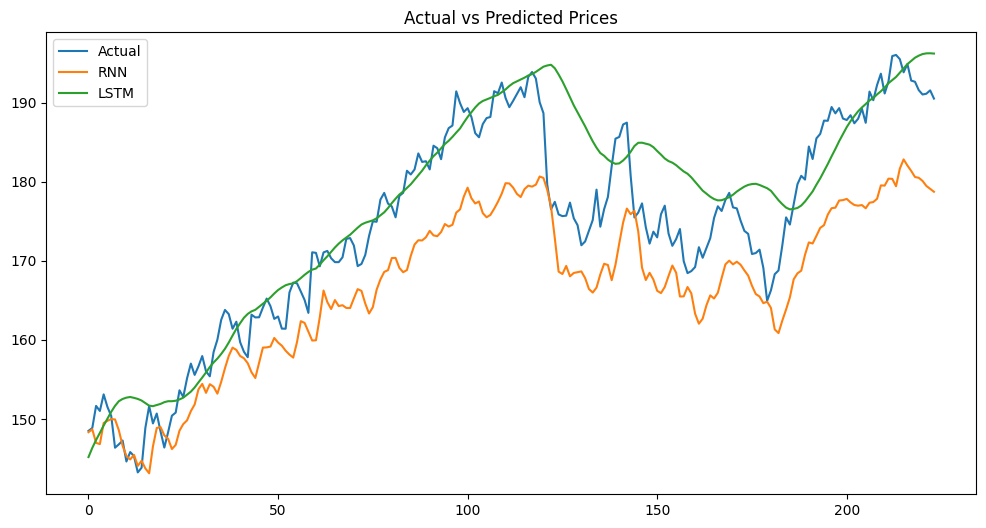

In [17]:
# Inverse scaling
rnn_pred_inv = scaler.inverse_transform(rnn_pred)
lstm_pred_inv = scaler.inverse_transform(lstm_pred)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual')
plt.plot(rnn_pred_inv, label='RNN')
plt.plot(lstm_pred_inv, label='LSTM')
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()


In [18]:
#FINAL CONCLUSION (WRITE THIS)

'''The LSTM model outperformed the Simple RNN in terms of lower Test MSE and MAE.
LSTM better captured long-term temporal dependencies due to its gated architecture.
Early stopping prevented overfitting by halting training when validation loss plateaued.
The ReduceLROnPlateau scheduler improved convergence stability by reducing learning rate during stagnation.'''

'The LSTM model outperformed the Simple RNN in terms of lower Test MSE and MAE.\nLSTM better captured long-term temporal dependencies due to its gated architecture.\nEarly stopping prevented overfitting by halting training when validation loss plateaued.\nThe ReduceLROnPlateau scheduler improved convergence stability by reducing learning rate during stagnation.'